## 1.Data Loading

In [1]:
### Set up path, no need to read file later
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
import os
#coding=utf-8
# Ignore all warnings
warnings.filterwarnings("ignore")
warnings.simplefilter("always")  # Force display of all warnings
np.seterr(all="ignore")
plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False    
os.chdir(r'C:\Users\karen\Desktop\dissertation\Writing\结果打包')
data=pd.read_excel('automobile_financial_warning_2024.xlsx')

In [2]:
### View imported data
data.head()

,Stock Code,Company Name,Reporting Date,Current Ratio,Cash Ratio,Debt-to-Asset Ratio,Accounts Receivable Turnover,Inventory Turnover,Accounts Payable Turnover,Total Asset Turnover,...,Return on Equity (ROE),Profit-to-Cost Ratio,Total Asset Growth Rate,Revenue Growth Rate,Net Profit Cash Coverage Ratio,Capital Accumulation Rate,Revenue Cash Coverage Ratio,Firm Size,Total Asset Cash Recovery Rate,ST_label_T2
0,30,FuAoGuFen,2013-12-31,1.449072,0.139648,0.402571,4.682980,7.189538,4.075542,0.735239,...,0.138980,0.123633,0.134041,0.127177,-0.126878,0.131234,0.747743,22.684817,-0.010535,0
1,30,FuAoGuFen,2014-12-31,1.693147,0.293973,0.345046,4.861329,6.891466,4.040693,0.689029,...,0.141197,0.146090,0.022610,0.010848,0.535182,0.121074,0.979754,22.707175,0.049492,0
2,30,FuAoGuFen,2015-12-31,1.927048,0.474869,0.343888,3.616360,6.180370,3.200565,0.535722,...,0.098955,0.126618,0.111986,0.391913,0.635592,0.113953,1.020350,22.813323,0.041266,0
3,30,FuAoGuFen,2016-12-31,1.751659,0.473297,0.363500,4.430190,7.323275,3.431999,0.645536,...,0.117164,0.125496,0.122148,0.235995,0.887906,0.088605,0.865692,22.928567,0.066216,0
4,30,FuAoGuFen,2017-12-31,1.686763,0.467493,0.389791,4.505213,9.246369,3.408152,0.694039,...,0.129481,0.128756,0.142330,0.254516,0.565270,0.095147,0.779652,23.061638,0.044662,0


### 2、Split the dataset into the training and testing sets
# Use data from 2021 and 2023 as the training set and data from 2022–2024 as the testing set.
# Standardize the training set, and apply the same scaling parameters to the testing set to ensure consistent feature scaling.

In [3]:
### 
import pandas as pd
from sklearn.preprocessing import StandardScaler
#Convert to datetime format
data["Reporting Date"] = pd.to_datetime(data["Reporting Date"], errors="coerce")

# Filter training set(2013-2021) + testing set(2022-2024)
train = data[(data["Reporting Date"] >= "2013-01-01") & 
             (data["Reporting Date"] <= "2021-12-31")].copy()

test = data[(data["Reporting Date"] >= "2022-01-01") & 
            (data["Reporting Date"] <= "2024-12-31")].copy()

feature_cols = data.columns[3:-1]

# Initialize scaler
scaler = StandardScaler()

# Standardize training set
train[feature_cols] = scaler.fit_transform(train[feature_cols])

#  Standardize testing set using rules from training set
test[feature_cols] = scaler.transform(test[feature_cols])

# View results
print("Train set shape（2013-2021）：", train.shape)
print("Test set shape（2022-2024）：", test.shape)

Train set shape（2013-2021）： (2075, 21)
Test set shape（2022-2024）： (896, 21)


## 3. Handling Imbalanced Samples
The dataset is characterized by an imbalanced class distribution. Therefore, SMOTE is applied only to the training set to balance the classes, while the testing set is kept unchanged to ensure an unbiased evaluation of the model's predictive performance.

In [4]:
### Handle class imbalance
print("===== Training set class distribution before SMOTE =====")
print(train['ST_label_T2'].value_counts())
print("Class proportions：\n", train['ST_label_T2'].value_counts(normalize=True))

===== Training set class distribution before SMOTE =====
ST_label_T2
0    2022
1      53
Name: count, dtype: int64
Class proportions：
 ST_label_T2
0    0.974458
1    0.025542
Name: proportion, dtype: float64


In [5]:
from imblearn.over_sampling import SMOTE
feature_cols = train.columns[3:-1]
train['ST_label_T2'] = train['ST_label_T2'].astype(int)  # Convert labels to integer (0/1)
test['ST_label_T2'] = test['ST_label_T2'].astype(int)
X_train = train[feature_cols]
y_train = train['ST_label_T2']  # Target variable
X_test = test[feature_cols]
y_test = test['ST_label_T2']  # Target variable
# ========================
# Apply SMOTE (1:1 balancing)
# ========================
smote = SMOTE(random_state=50, sampling_strategy=1)  #  Set random_state for reproducibility
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# ========================
#  View balanced class distribution
# ========================
print("\n===== Training set class distribution after SMOTE =====")
print(pd.Series(y_train_balanced).value_counts())


===== Training set class distribution after SMOTE =====
ST_label_T2
0    2022
1    2022
Name: count, dtype: int64


## 4. Logistic Regression Model Training and Evaluation

Optimal Threshold： 0.6712
===== Logistic Regression Test Results（Optimal Threshold） =====
Best parameters: {'C': 0.1}
Accuracy: 0.8583
Precision: 0.1119
Recall: 1.0000
F1: 0.2013
AUC: 0.9335


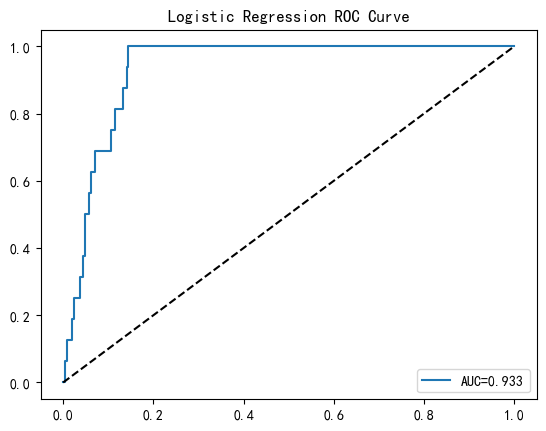

In [6]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve)

# Train the model
params = {"C": [0.1, 1, 10]}
model = LogisticRegression(
    max_iter=2000,
     random_state=50                  
 )
grid = GridSearchCV(model, params, cv=3, scoring="roc_auc", n_jobs=-1)
grid.fit(X_train_balanced, y_train_balanced)
lr = grid.best_estimator_

#  Predict class probabilities
y_prob_lr = lr.predict_proba(X_test)[:,1]

# ========================
# Determine the optimal ROC threshold
# ========================
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

# Optimal threshold based on Youden's Index
# (Sensitivity + Specificity − 1)
optimal_idx = (tpr - fpr).argmax()
optimal_threshold = thresholds[optimal_idx]

print("Optimal Threshold：", round(optimal_threshold, 4))

# Generate predicted labels using the optimal threshold
y_pred_lr = (y_prob_lr >= optimal_threshold).astype(int)

# ========================
#  Evaluate model performance
# (using the optimal threshold)
# ========================
print("===== Logistic Regression Test Results（Optimal Threshold） =====")
print("Best parameters:", grid.best_params_)
print("Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred_lr)))
print("Precision: {:.4f}".format(precision_score(y_test, y_pred_lr)))
print("Recall: {:.4f}".format(recall_score(y_test, y_pred_lr)))
print("F1: {:.4f}".format(f1_score(y_test, y_pred_lr)))
print("AUC: {:.4f}".format(roc_auc_score(y_test, y_prob_lr)))

# Plot ROC
#plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test,y_prob_lr):.3f}")
#plt.scatter(fpr[optimal_idx], tpr[optimal_idx], marker='o', color='red', label="最优分割点")
plt.plot([0,1],[0,1],"k--")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.show()

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
def plot_cm(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                  display_labels=["Negative", "Positive"]
    )
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

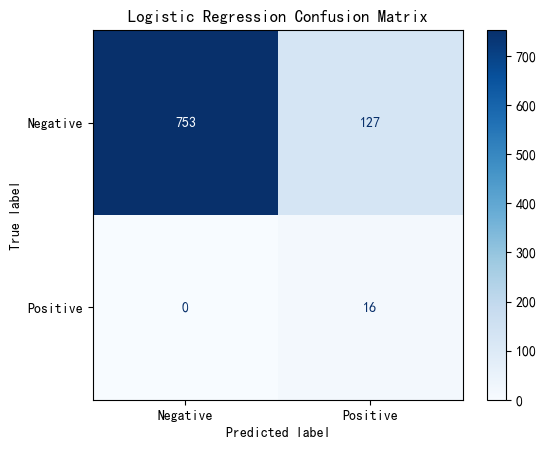

In [8]:
# Plot confusion matrix
plot_cm(y_test, y_pred_lr, "Logistic Regression Confusion Matrix")

## 5. Support Vector Machine (SVM) Model Training and Evaluation

SVM Optimal Threshold： 0.0
===== SVM Test Results (Optimal Threshold)） =====
Best parameters: {'C': 5, 'gamma': 0.1, 'kernel': 'rbf'}
Accuracy: 0.7522
Precision: 0.0598
Recall: 0.8750
F1: 0.1120
AUC: 0.8695


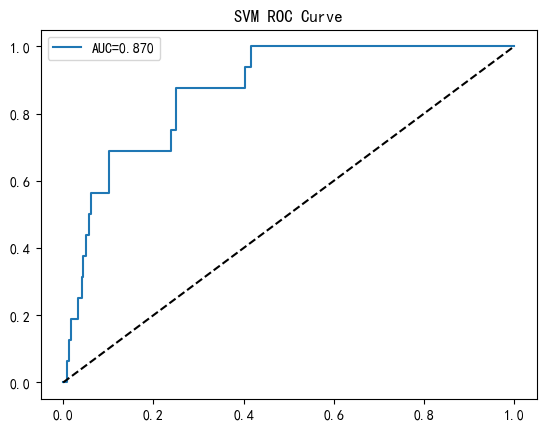

In [9]:
from sklearn.svm import SVC
params = {
    'C': [0.1, 0.5, 1, 2, 5],            # Regularization parameter
    'kernel': ['rbf', 'linear'],         # Kernel function
    'gamma': ['scale', 'auto', 0.01, 0.1] # Kernel coefficient

}
model = SVC(probability=True)
grid = GridSearchCV(model, params, cv=3, scoring="roc_auc", n_jobs=-1)
grid.fit(X_train_balanced, y_train_balanced)
svm = grid.best_estimator_

# Predict class probabilities
y_prob_svm = svm.predict_proba(X_test)[:,1]

# ========================
# Determine the optimal ROC threshold
# (Youden's Index)
# ========================
fpr, tpr, thresholds = roc_curve(y_test, y_prob_svm)
optimal_idx = (tpr - fpr).argmax()           # Optimal index
optimal_threshold = thresholds[optimal_idx] # Optimal threshold
print("SVM Optimal Threshold：", round(optimal_threshold, 4))

# Generate predicted labels using the optimal threshold
y_pred_svm = (y_prob_svm >= optimal_threshold).astype(int)

# ========================
# Evaluate model performance
# (using the optimal threshold)
# ========================
print("===== SVM Test Results (Optimal Threshold)） =====")
print("Best parameters:", grid.best_params_)
print("Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred_svm)))
print("Precision: {:.4f}".format(precision_score(y_test, y_pred_svm)))
print("Recall: {:.4f}".format(recall_score(y_test, y_pred_svm)))
print("F1: {:.4f}".format(f1_score(y_test, y_pred_svm)))
print("AUC: {:.4f}".format(roc_auc_score(y_test, y_prob_svm)))

# Plot ROC 
#plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test,y_prob_svm):.3f}")
#plt.scatter(fpr[optimal_idx], tpr[optimal_idx], marker='o', color='red', label='Optimal Threshold') 
plt.plot([0,1],[0,1],"k--")
plt.title("SVM ROC Curve")
plt.legend()
plt.show()

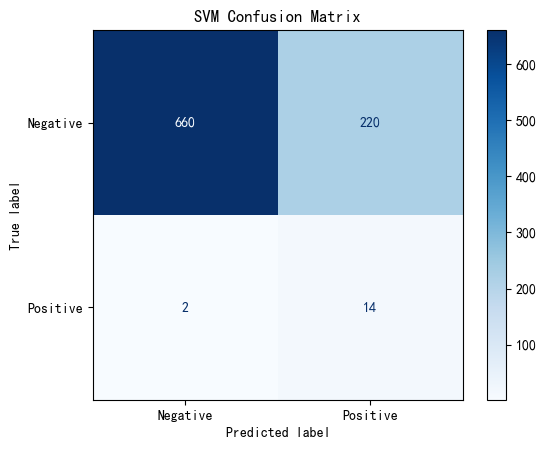

In [10]:
# Plot confusion matrix
plot_cm(y_test, y_pred_svm, "SVM Confusion Matrix")

## 6. Random Forest Model Training and Evaluation

Random Forest Optimal Threshold： 0.3615
===== Random Forest Test Results (Optimal Threshold) =====
Best parameters: {'max_depth': 9, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Accuracy: 0.8728
Precision: 0.1172
Recall: 0.9375
F1: 0.2083
AUC: 0.9363


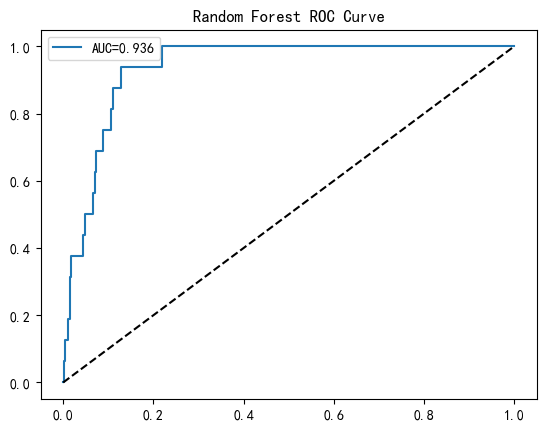

In [11]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve)

#params = {"n_estimators": [100], "max_depth": [5, 10]}

params = {
    'n_estimators': [100, 200],     # Number of trees
    'max_depth': [3, 5, 7, 9],         # Maximum tree depth
    'min_samples_split': [2, 5],      # Minimum samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]     # Minimum samples required at a leaf node

}
model = RandomForestClassifier(random_state=50)
grid = GridSearchCV(model, params, cv=3, scoring="roc_auc", n_jobs=-1)
grid.fit(X_train_balanced, y_train_balanced)
rf = grid.best_estimator_

# Predict class probabilities
y_prob_rf = rf.predict_proba(X_test)[:,1]

# ========================
# Determine the optimal ROC threshold
# (Youden's Index)
# ========================
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
optimal_idx = (tpr - fpr).argmax()           # Optimal index
optimal_threshold = thresholds[optimal_idx]  # Optimal threshold
print("Random Forest Optimal Threshold：", round(optimal_threshold, 4))

#  Generate predicted labels using the optimal threshold
y_pred_rf = (y_prob_rf >= optimal_threshold).astype(int)

# ========================
# Evaluate model performance
# (using the optimal threshold)
# ========================
print("===== Random Forest Test Results (Optimal Threshold) =====")
print("Best parameters:", grid.best_params_)
print("Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred_rf)))
print("Precision: {:.4f}".format(precision_score(y_test, y_pred_rf)))
print("Recall: {:.4f}".format(recall_score(y_test, y_pred_rf)))
print("F1: {:.4f}".format(f1_score(y_test, y_pred_rf)))
print("AUC: {:.4f}".format(roc_auc_score(y_test, y_prob_rf)))

# Plot ROC curve and highlight the optimal threshold
#plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test,y_prob_rf):.3f}")
#plt.scatter(fpr[optimal_idx], tpr[optimal_idx], marker='o', color='red', label='最优分割点') 
plt.plot([0,1],[0,1],"k--")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.show()

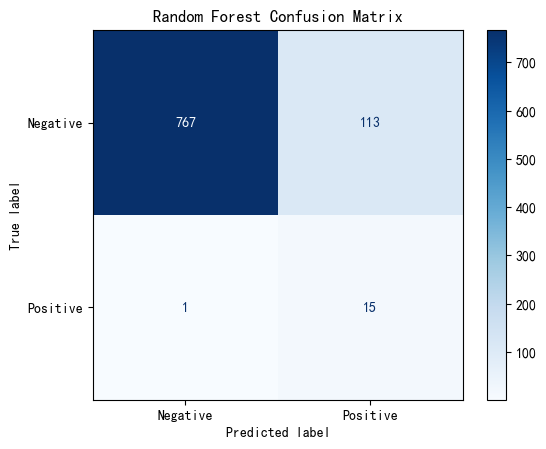

In [12]:
# Plot confusion matrix
plot_cm(y_test, y_pred_rf, "Random Forest Confusion Matrix")

##7.XGBoost Model Training and Evaluation

In [13]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


C:\Users\karen\AppData\Roaming\Python\Python313\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedWriter name=5>
  res = process_handler(cmd, _system_body)
C:\Users\karen\AppData\Roaming\Python\Python313\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=6>
  res = process_handler(cmd, _system_body)
C:\Users\karen\AppData\Roaming\Python\Python313\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=7>
  res = process_handler(cmd, _system_body)


XGB optimal threshold： 0.1644
===== XGBoost Test Results (Optimal Threshold) =====
Best parameters: {'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.8}
Accuracy: 0.8906
Precision: 0.1273
Recall: 0.8750
F1: 0.2222
AUC: 0.9286


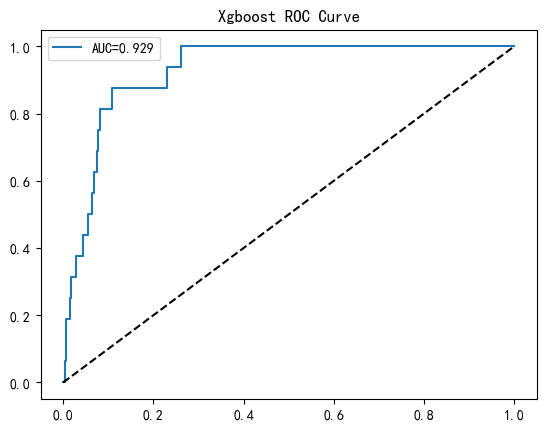

In [14]:
from xgboost import XGBClassifier

params = {
    'n_estimators': [100, 200],
    'max_depth': [2,3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9],
    'min_child_weight': [1, 3,5],
    'gamma': [0.1, 0.2]
}
model = XGBClassifier(random_state=50)
grid = GridSearchCV(model, params, cv=3, scoring="roc_auc", n_jobs=-1)
grid.fit(X_train_balanced, y_train_balanced)
xgb = grid.best_estimator_

# Predict class probabilities
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

# ========================
# Determine the optimal ROC threshold
# (Youden's Index)
# ========================
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)
optimal_idx = (tpr - fpr).argmax()
optimal_threshold = thresholds[optimal_idx]

# Generate predicted labels using the optimal threshold
y_pred_xgb = (y_prob_xgb >= optimal_threshold).astype(int)

# Display the optimal threshold
print("XGB optimal threshold：", round(optimal_threshold, 4))

# Evaluate model performance
# (using the optimal threshold)
print("===== XGBoost Test Results (Optimal Threshold) =====")
print("Best parameters:", grid.best_params_)
print("Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred_xgb)))
print("Precision: {:.4f}".format(precision_score(y_test, y_pred_xgb)))
print("Recall: {:.4f}".format(recall_score(y_test, y_pred_xgb)))
print("F1: {:.4f}".format(f1_score(y_test, y_pred_xgb)))
print("AUC: {:.4f}".format(roc_auc_score(y_test, y_prob_xgb)))

# Plot ROC curve
#plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test,y_prob_xgb):.3f}")
#plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color="red", label="optimal threshold") 
plt.plot([0,1],[0,1],"k--")
plt.title("Xgboost ROC Curve")
plt.legend()
plt.show()

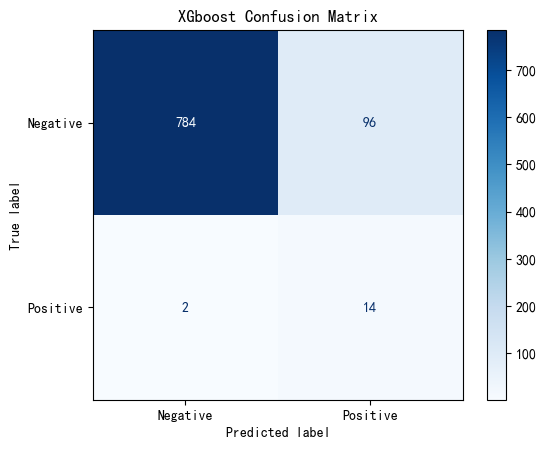

In [15]:
# Plot confusion matrix
plot_cm(y_test, y_pred_xgb, "XGboost Confusion Matrix")

## 8. LightGBM Model Training and Evaluation

In [16]:
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


C:\Users\karen\AppData\Roaming\Python\Python313\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedWriter name=5>
  res = process_handler(cmd, _system_body)
C:\Users\karen\AppData\Roaming\Python\Python313\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=6>
  res = process_handler(cmd, _system_body)
C:\Users\karen\AppData\Roaming\Python\Python313\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=7>
  res = process_handler(cmd, _system_body)


 LightGBM Optimal Threshold： 0.0083
===== LightGBM Test Results (Optimal Threshold) =====
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
Accuracy: 0.8538
Precision: 0.0922
Recall: 0.8125
F1: 0.1656
AUC: 0.8904


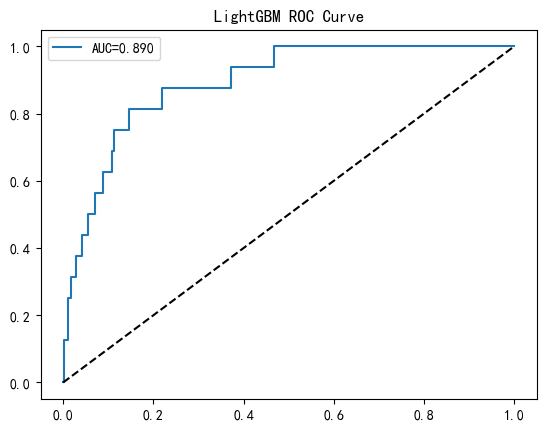

In [17]:
from lightgbm import LGBMClassifier

# Hyperparameter tuning
params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9]
}

# Disable training logs
model = LGBMClassifier(random_state=50, verbose=-1)

# Perform grid search
grid = GridSearchCV(model, params, cv=3, scoring="roc_auc", n_jobs=-1, verbose=0)
grid.fit(X_train_balanced, y_train_balanced)
lgb = grid.best_estimator_

# Predict class probabilities
y_prob_lgb = lgb.predict_proba(X_test)[:,1]

# ========================
#  Determine the optimal ROC threshold
# (Youden's Index)
# ========================
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lgb)
optimal_idx = (tpr - fpr).argmax()
optimal_threshold = thresholds[optimal_idx]
y_pred_lgb = (y_prob_lgb >= optimal_threshold).astype(int)

# Generate predicted labels using the optimal threshold
print(" LightGBM Optimal Threshold：", round(optimal_threshold, 4))

# Model evaluation
print("===== LightGBM Test Results (Optimal Threshold) =====")
print("Best parameters:", grid.best_params_)
print("Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred_lgb)))
print("Precision: {:.4f}".format(precision_score(y_test, y_pred_lgb)))
print("Recall: {:.4f}".format(recall_score(y_test, y_pred_lgb)))
print("F1: {:.4f}".format(f1_score(y_test, y_pred_lgb)))
print("AUC: {:.4f}".format(roc_auc_score(y_test, y_prob_lgb)))

# Plot ROC curve
#plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test,y_prob_lgb):.3f}")
#plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', label='Optimal Threshold')
plt.plot([0,1],[0,1],"k--")
plt.title("LightGBM ROC Curve")
plt.legend()
plt.show()

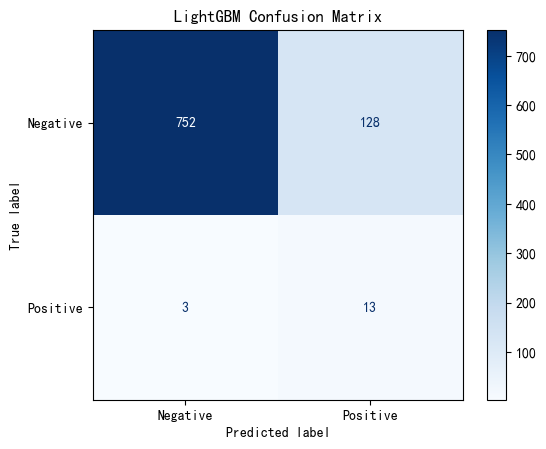

In [18]:
# Plot confusion matrix
plot_cm(y_test, y_pred_lgb, "LightGBM Confusion Matrix")

## ## 9. Comparison of the five Model Performance

In [19]:
# Save the performance metrics of the five models
results = pd.DataFrame({
    'Model': ['LR', 'SVM', 'RF', 'XGB', 'LGB'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_lgb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_lgb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_lgb)
    ],
    'F1': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_lgb)
    ],
    'AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_svm),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_lgb)
    ]
})

# Display results with four decimal places
results = results.round(4)
print("\n==================== Model Performance Summary ====================\n")
results


==================== Model Performance Summary ====================



,Model,Accuracy,Precision,Recall,F1,AUC
0,LR,0.8583,0.1119,1.0000,0.2013,0.9335
1,SVM,0.7522,0.0598,0.8750,0.1120,0.8695
2,RF,0.8728,0.1172,0.9375,0.2083,0.9363
3,XGB,0.8906,0.1273,0.8750,0.2222,0.9286
4,LGB,0.8538,0.0922,0.8125,0.1656,0.8904


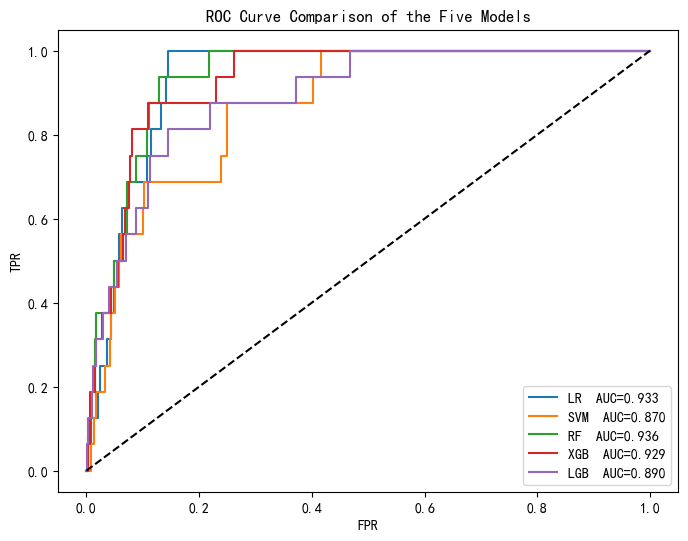

In [20]:
plt.figure(figsize=(8, 6))

# Plot ROC curves for all models
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
plt.plot(fpr_lr, tpr_lr, label=f'LR  AUC={roc_auc_score(y_test, y_prob_lr):.3f}')

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
plt.plot(fpr_svm, tpr_svm, label=f'SVM  AUC={roc_auc_score(y_test, y_prob_svm):.3f}')

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f'RF  AUC={roc_auc_score(y_test, y_prob_rf):.3f}')

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGB  AUC={roc_auc_score(y_test, y_prob_xgb):.3f}')

fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_prob_lgb)
plt.plot(fpr_lgb, tpr_lgb, label=f'LGB  AUC={roc_auc_score(y_test, y_prob_lgb):.3f}')

plt.plot([0,1],[0,1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve Comparison of the Five Models')
plt.legend()
plt.savefig("ROC_Curve_Comparison_Five_Models.png", dpi=300, bbox_inches="tight")
plt.show()


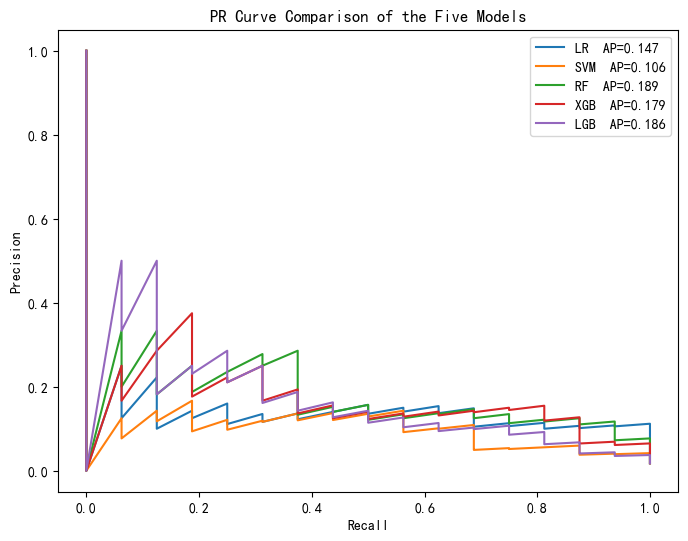

In [21]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8, 6))

# Plot PR curves for all models
# Logistic Regression
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
ap_lr = average_precision_score(y_test, y_prob_lr)
plt.plot(recall_lr, precision_lr, label=f'LR  AP={ap_lr:.3f}')

# Support Vector Machine
precision_svm, recall_svm, _ = precision_recall_curve(y_test, y_prob_svm)
ap_svm = average_precision_score(y_test, y_prob_svm)
plt.plot(recall_svm, precision_svm, label=f'SVM  AP={ap_svm:.3f}')

# Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
ap_rf = average_precision_score(y_test, y_prob_rf)
plt.plot(recall_rf, precision_rf, label=f'RF  AP={ap_rf:.3f}')

# XGBoost
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
ap_xgb = average_precision_score(y_test, y_prob_xgb)
plt.plot(recall_xgb, precision_xgb, label=f'XGB  AP={ap_xgb:.3f}')

# LightGBM
precision_lgb, recall_lgb, _ = precision_recall_curve(y_test, y_prob_lgb)
ap_lgb = average_precision_score(y_test, y_prob_lgb)
plt.plot(recall_lgb, precision_lgb, label=f'LGB  AP={ap_lgb:.3f}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curve Comparison of the Five Models')
plt.legend()
plt.savefig("PR_Curve_Comparison_Five_Models.png", dpi=300, bbox_inches="tight")
plt.show()

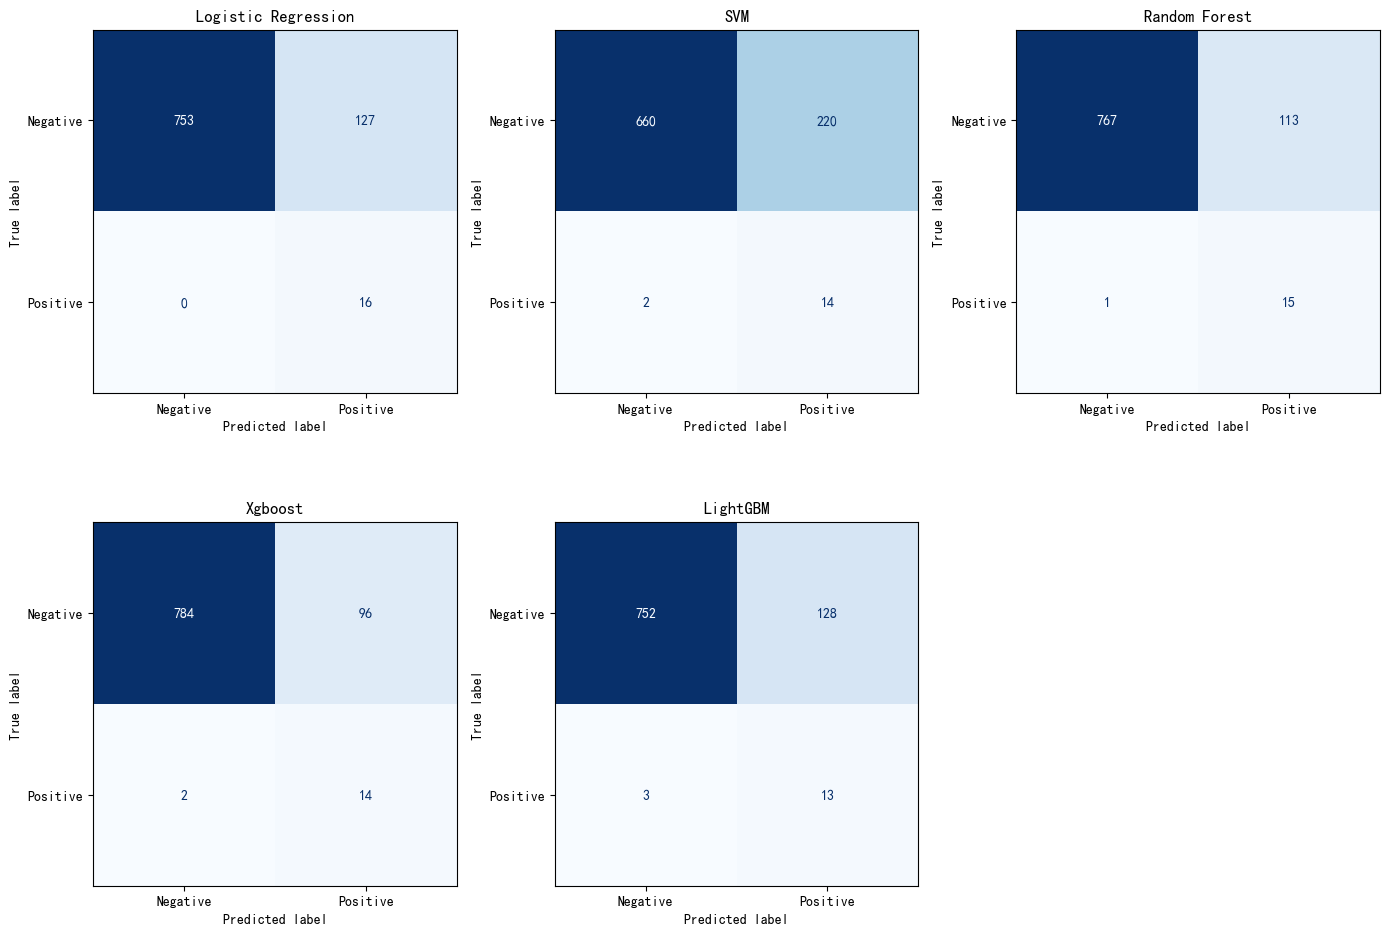

<Figure size 600x500 with 0 Axes>

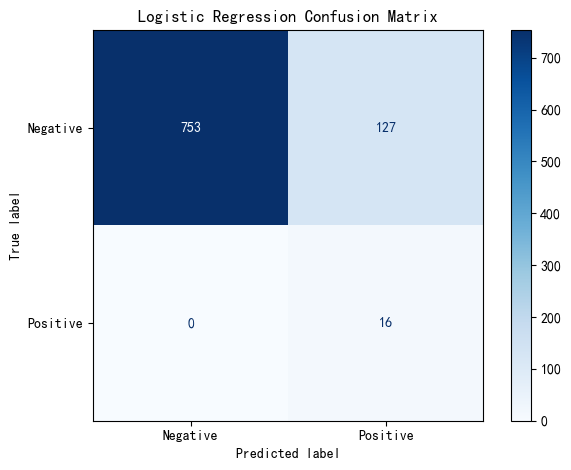

<Figure size 600x500 with 0 Axes>

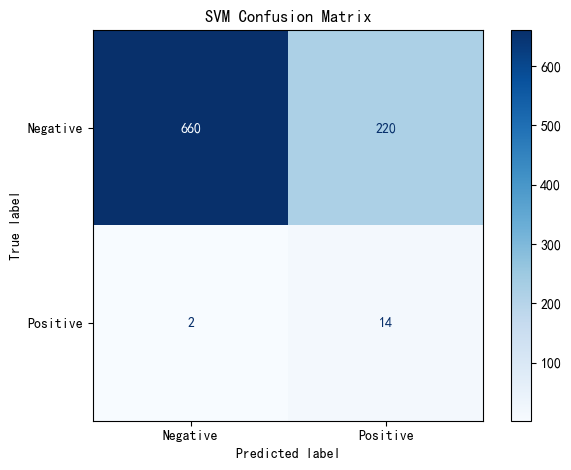

<Figure size 600x500 with 0 Axes>

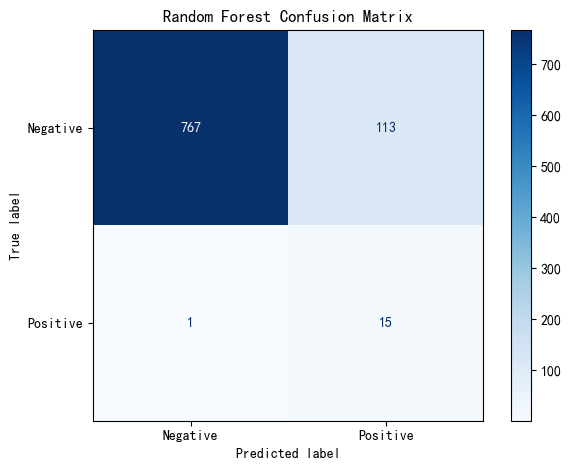

<Figure size 600x500 with 0 Axes>

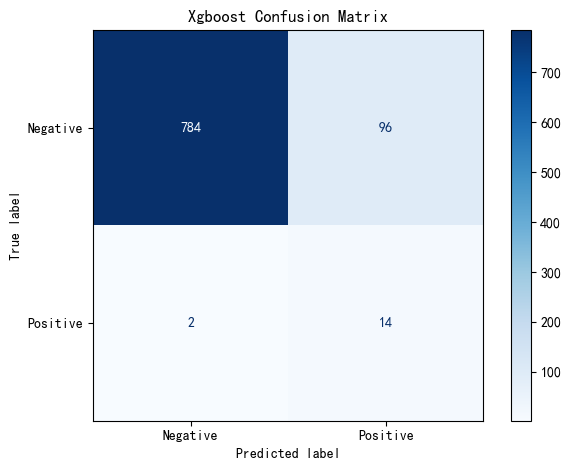

<Figure size 600x500 with 0 Axes>

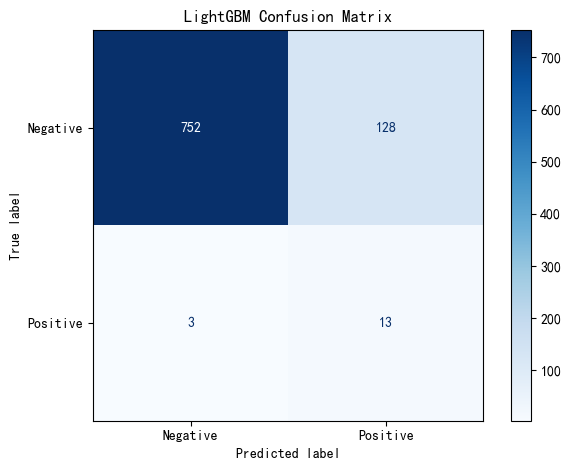

In [22]:
# Model information
models_info = [
    ("Logistic Regression", y_pred_lr, "lr_cm"),
    ("SVM", y_pred_svm, "svm_cm"),
    ("Random Forest", y_pred_rf, "rf_cm"),
    ("Xgboost", y_pred_xgb, "xgb_cm"),
    ("LightGBM", y_pred_lgb, "lgb_cm")  
]

# Plot confusion matrices in a 2×3 grid
fig, axes = plt.subplots(2, 3, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, y_pred, _) in enumerate(models_info):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
    disp.plot(ax=axes[idx], cmap=plt.cm.Blues, colorbar=False)
    axes[idx].set_title(name, fontsize=12)

axes[5].set_visible(False)

plt.tight_layout()
# Save the combined figure
plt.savefig("all_models_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()



# Plot each confusion matrix separately
for name, y_pred, filename in models_info:
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"{name} Confusion Matrix")
    plt.tight_layout()
   # Save each figure individually
    plt.savefig(f"{filename}.png", dpi=300, bbox_inches="tight")
    plt.show()

## 10. SHAP Analysis Based on the Best-Performing Model (Random Forest)

In [23]:
!pip install shap

C:\Users\karen\AppData\Roaming\Python\Python313\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedWriter name=5>
  res = process_handler(cmd, _system_body)
C:\Users\karen\AppData\Roaming\Python\Python313\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=6>
  res = process_handler(cmd, _system_body)
C:\Users\karen\AppData\Roaming\Python\Python313\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=7>
  res = process_handler(cmd, _system_body)


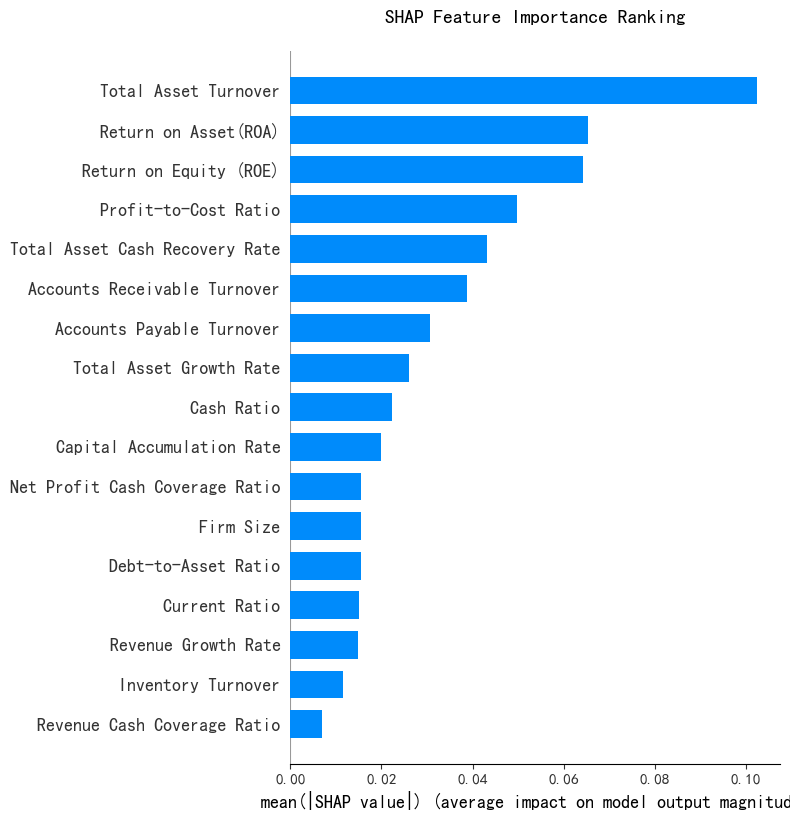

In [24]:
import shap
import matplotlib.pyplot as plt
import numpy as np

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values = shap_values[:, :, 1]

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance Ranking", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig("shap_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

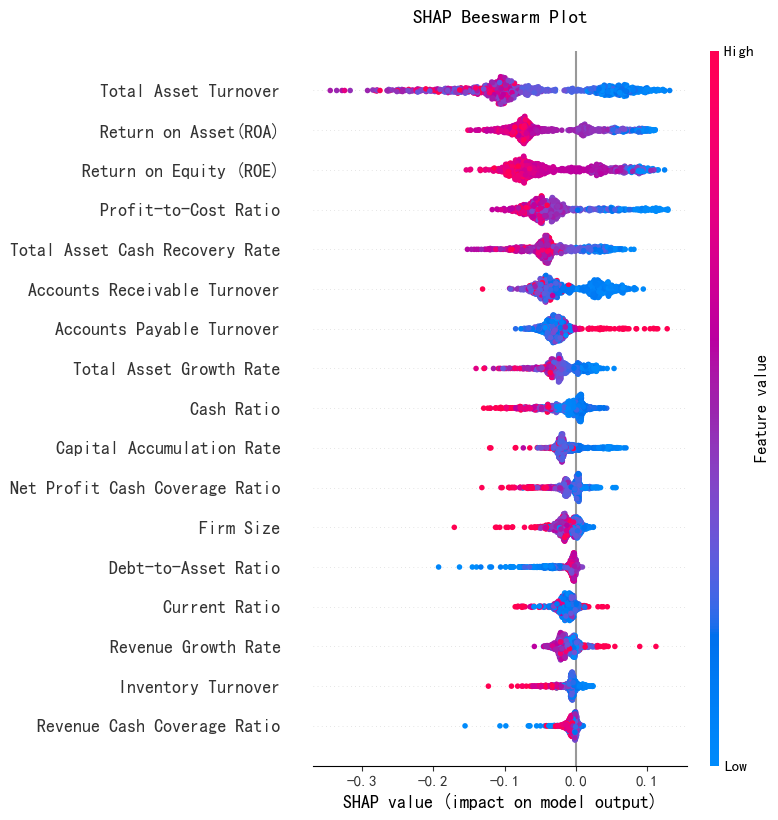

In [25]:
#  2. SHAP Beeswarm Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_test, 
    show=False 
)

# Title and Layout
plt.title("SHAP Beeswarm Plot", fontsize=14, pad=20)
plt.tight_layout()

# Save Figure
plt.savefig("shap_beeswarm.png", dpi=300, bbox_inches="tight")  
# Display Figure
plt.show()

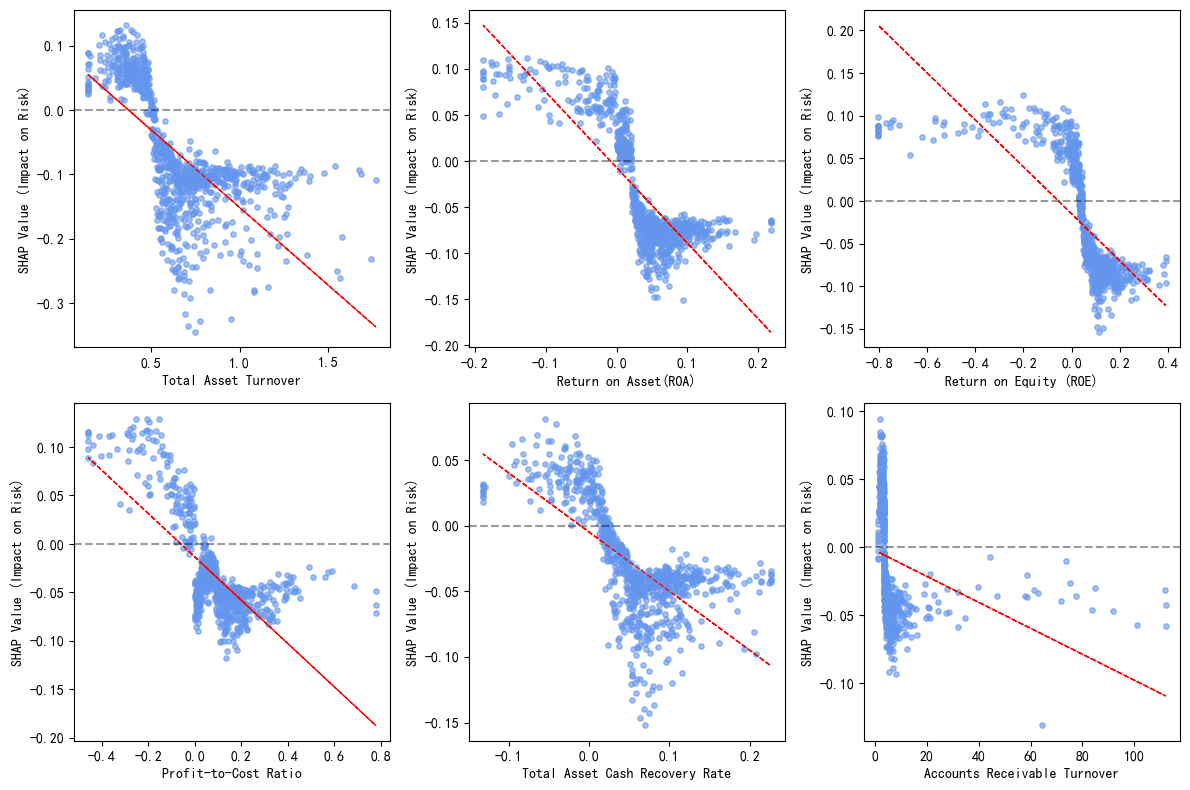

In [26]:
from sklearn.linear_model import LinearRegression
# Since the data were standardized, restore the original values for the x-axis
X_test_original = scaler.inverse_transform(X_test)
X_test_original = pd.DataFrame(X_test_original, columns=X_test.columns)
shap_importance = np.abs(shap_values).mean(0)
top6_idx = np.argsort(shap_importance)[-6:][::-1]
top6_features = X_test.columns[top6_idx]
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

# Store results
results = []

for idx, feat in enumerate(top6_features):
    x = X_test_original[feat].values
    y = shap_values[:, X_test.columns.get_loc(feat)]

    # Scatter Plot
    axes[idx].scatter(x, y, c="cornflowerblue", alpha=0.6, s=15)

    # Linear Regression Fit
    lr = LinearRegression()
    lr.fit(x.reshape(-1, 1), y)
    y_pred = lr.predict(x.reshape(-1, 1))

    # Save Results
    results.append({
        "Feature": feat,
        "Slope": lr.coef_[0],
        "Intercept": lr.intercept_
    })

    # Regression Line
    axes[idx].plot(x, y_pred, color="red", linewidth=1, linestyle='--')
    axes[idx].axhline(0, color="black", linestyle="--", alpha=0.4)

    axes[idx].set_xlabel(feat)
    axes[idx].set_ylabel("SHAP Value (Impact on Risk)")

plt.tight_layout()
plt.savefig("shap_top6_dependence.png", dpi=300, bbox_inches="tight")  
plt.show()


In [27]:
## Five-level Financial Risk Warning System

In [28]:
# ============================================================
# CHAPTER 5: SERES GROUP CASE STUDY
# Historical risk prediction, five-level warning and SHAP
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from IPython.display import display, FileLink


# ============================================================
# 0. BASIC SETTINGS
# ============================================================

SERES_CODE = "601127"

OUTPUT_DIR = "Chapter5_Seres_Revised"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Use the optimal threshold calculated in Chapter 4
if "optimal_threshold" in globals():
    RF_OPTIMAL_THRESHOLD = float(
        np.asarray(optimal_threshold).reshape(-1)[0]
    )
else:
    # Use this only if the original variable is unavailable
    RF_OPTIMAL_THRESHOLD = 0.3615

print(
    "Random Forest optimal threshold:",
    round(RF_OPTIMAL_THRESHOLD, 4)
)


# ============================================================
# 1. REDEFINE THE FIVE-LEVEL WARNING SYSTEM
# ============================================================

# The optimal threshold separates Moderate and High Warning
WARNING_BINS = [
    0.0,
    0.10,
    0.20,
    RF_OPTIMAL_THRESHOLD,
    0.60,
    1.000001
]

WARNING_LABELS = [
    "No Warning",
    "Low Warning",
    "Moderate Warning",
    "High Warning",
    "Severe Warning"
]

WARNING_SCORE_MAP = {
    "No Warning": 1,
    "Low Warning": 2,
    "Moderate Warning": 3,
    "High Warning": 4,
    "Severe Warning": 5
}

warning_system_table = pd.DataFrame({
    "Risk Score Range": [
        "0.0000–0.1000",
        "0.1000–0.2000",
        f"0.2000–{RF_OPTIMAL_THRESHOLD:.4f}",
        f"{RF_OPTIMAL_THRESHOLD:.4f}–0.6000",
        "0.6000–1.0000"
    ],
    "Warning Level": WARNING_LABELS,
    "Risk Description": [
        "Very low financial risk",
        "Low financial risk",
        "Noticeable financial pressure",
        "High financial risk",
        "Very high financial risk"
    ]
})

print("\n===== Revised Five-Level Warning System =====")
display(warning_system_table)


# ============================================================
# 2. CHECK REQUIRED CHAPTER 4 OBJECTS
# ============================================================

required_objects = [
    "data",
    "feature_cols",
    "scaler",
    "rf"
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise NameError(
        "The following objects are unavailable: "
        + ", ".join(missing_objects)
        + ". Please run the full Chapter 4 code first."
    )

feature_cols = list(feature_cols)

print("\nRequired Chapter 4 objects are available.")
print("Number of model features:", len(feature_cols))


# ============================================================
# 3. IDENTIFY BASIC DATA COLUMNS
# ============================================================

date_col = "Reporting Date"

if date_col not in data.columns:
    raise KeyError(
        "'Reporting Date' was not found. "
        "Please replace date_col with the actual date column name."
    )

possible_code_cols = [
    "Stock Code",
    "Stock code",
    "Code",
    "Symbol",
    "证券代码",
    "股票代码"
]

code_col = next(
    (
        col for col in possible_code_cols
        if col in data.columns
    ),
    None
)

if code_col is None:
    code_col = data.columns[0]
    print(
        f"Stock code column was not automatically identified. "
        f"Using: {code_col}"
    )

possible_name_cols = [
    "Company Name",
    "Stock Name",
    "Company",
    "Short Name",
    "证券简称",
    "公司名称"
]

name_col = next(
    (
        col for col in possible_name_cols
        if col in data.columns
    ),
    None
)

if name_col is None:
    name_col = data.columns[1]
    print(
        f"Company name column was not automatically identified. "
        f"Using: {name_col}"
    )

print("\nColumns used:")
print("Stock code column:", code_col)
print("Company name column:", name_col)
print("Reporting date column:", date_col)


# ============================================================
# 4. PREPARE THE COMPLETE DATASET
# ============================================================

case_data = data.copy()

case_data[date_col] = pd.to_datetime(
    case_data[date_col],
    errors="coerce"
)

case_data["_Stock_Code_Clean"] = (
    case_data[code_col]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
    .str.extract(r"(\d+)", expand=False)
    .str.zfill(6)
)

case_data["_Year"] = case_data[date_col].dt.year


# ============================================================
# 5. SELECT ALL AVAILABLE SERES/SOKON YEARS
# ============================================================

seres_raw = case_data[
    case_data["_Stock_Code_Clean"] == SERES_CODE
].copy()

seres_raw = (
    seres_raw
    .dropna(subset=["_Year"])
    .sort_values(date_col)
    .reset_index(drop=True)
)

if seres_raw.empty:
    raise ValueError(
        "No observations for stock code 601127 were found."
    )

if seres_raw["_Year"].duplicated().any():
    duplicate_rows = seres_raw.loc[
        seres_raw["_Year"].duplicated(keep=False),
        [
            "_Year",
            date_col,
            name_col
        ]
    ]

    print("\nDuplicated annual records:")
    display(duplicate_rows)

    raise ValueError(
        "More than one observation exists for at least one year. "
        "Please retain only the annual year-end record."
    )

first_year = int(seres_raw["_Year"].min())
last_year = int(seres_raw["_Year"].max())

print("\n===== Seres/Sokon Observations =====")

display(
    seres_raw[
        [
            "_Stock_Code_Clean",
            name_col,
            date_col,
            "_Year"
        ]
    ]
)

print(f"Available period: {first_year}–{last_year}")
print("Number of observations:", len(seres_raw))


# ============================================================
# 6. CHECK MISSING YEARS
# ============================================================

expected_years = set(
    range(first_year, last_year + 1)
)

available_years = set(
    seres_raw["_Year"].astype(int)
)

missing_years = sorted(
    expected_years - available_years
)

if missing_years:
    print("Missing years:", missing_years)
else:
    print("No annual observations are missing.")


# ============================================================
# 7. EXTRACT THE SAME FEATURES USED BY THE RF MODEL
# ============================================================

missing_feature_columns = [
    feature
    for feature in feature_cols
    if feature not in seres_raw.columns
]

if missing_feature_columns:
    raise KeyError(
        "The following model features are missing:\n"
        + "\n".join(missing_feature_columns)
    )

X_seres_raw = (
    seres_raw[feature_cols]
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .copy()
)

missing_summary = X_seres_raw.isna().sum()
missing_summary = missing_summary[
    missing_summary > 0
]

if not missing_summary.empty:
    print("\nMissing values detected:")
    print(missing_summary)

    raise ValueError(
        "Missing values remain in the Seres data. "
        "Use the same processed dataset used in Chapter 4, "
        "or apply exactly the same imputation procedure."
    )

print("\nSeres feature matrix shape:", X_seres_raw.shape)


# ============================================================
# 8. APPLY THE ORIGINAL TRAINING-SET SCALER
# ============================================================

# Do not use fit() or fit_transform() here
X_seres_scaled_array = scaler.transform(
    X_seres_raw
)

X_seres_scaled = pd.DataFrame(
    X_seres_scaled_array,
    columns=feature_cols,
    index=seres_raw.index
)

print("Original scaler applied successfully.")


# ============================================================
# 9. RANDOM FOREST PREDICTION
# ============================================================

risk_probability = rf.predict_proba(
    X_seres_scaled
)[:, 1]

binary_prediction_optimal = (
    risk_probability >= RF_OPTIMAL_THRESHOLD
).astype(int)

binary_prediction_050 = (
    risk_probability >= 0.50
).astype(int)


# ============================================================
# 10. APPLY THE REVISED FIVE-LEVEL WARNING SYSTEM
# ============================================================

warning_level = pd.cut(
    risk_probability,
    bins=WARNING_BINS,
    labels=WARNING_LABELS,
    right=False,
    include_lowest=True,
    ordered=True
)

seres_results = pd.DataFrame({
    "Stock Code":
        seres_raw["_Stock_Code_Clean"].values,

    "Company Name":
        seres_raw[name_col].astype(str).values,

    "Reporting Date":
        seres_raw[date_col].values,

    "Year":
        seres_raw["_Year"].astype(int).values,

    "RF Risk Score":
        risk_probability,

    "RF Risk Score (%)":
        risk_probability * 100,

    "Binary Prediction (Optimal Threshold)":
        binary_prediction_optimal,

    "Binary Prediction (0.5 Threshold)":
        binary_prediction_050,

    "Warning Level":
        warning_level
})

seres_results["Warning Score"] = (
    seres_results["Warning Level"]
    .astype(str)
    .map(WARNING_SCORE_MAP)
)


# ============================================================
# 11. ADD ASSESSMENT STATUS
# ============================================================

def assessment_status(year):
    if year <= 2021:
        return "Retrospective in-sample assessment"

    if 2022 <= year <= 2024:
        return "Out-of-sample test-period assessment"

    return "Post-model-period case assessment"


seres_results["Assessment Status"] = (
    seres_results["Year"]
    .apply(assessment_status)
)


# ============================================================
# 12. CREATE A ROUNDED DISPLAY TABLE
# ============================================================

seres_results_display = seres_results.copy()

seres_results_display["RF Risk Score"] = (
    seres_results_display["RF Risk Score"]
    .round(4)
)

seres_results_display["RF Risk Score (%)"] = (
    seres_results_display["RF Risk Score (%)"]
    .round(2)
)

print(
    "\n===== Revised Seres Historical "
    "Financial Risk Results ====="
)

display(
    seres_results_display[
        [
            "Year",
            "Company Name",
            "RF Risk Score",
            "RF Risk Score (%)",
            "Binary Prediction (Optimal Threshold)",
            "Warning Level",
            "Assessment Status"
        ]
    ]
    .style
    .format({
        "RF Risk Score": "{:.4f}",
        "RF Risk Score (%)": "{:.2f}"
    })
    .set_properties(**{
        "font-size": "14px",
        "text-align": "center"
    })
)


# ============================================================
# 13. EXPORT RESULTS TO EXCEL
# ============================================================

results_file = os.path.join(
    OUTPUT_DIR,
    (
        f"Seres_Revised_Risk_Assessment_"
        f"{first_year}_{last_year}.xlsx"
    )
)

raw_feature_export = pd.concat(
    [
        seres_results[
            [
                "Year",
                "Company Name"
            ]
        ].reset_index(drop=True),

        X_seres_raw.reset_index(drop=True)
    ],
    axis=1
)

scaled_feature_export = pd.concat(
    [
        seres_results[
            ["Year"]
        ].reset_index(drop=True),

        X_seres_scaled.reset_index(drop=True)
    ],
    axis=1
)

with pd.ExcelWriter(
    results_file,
    engine="openpyxl"
) as writer:

    seres_results_display.to_excel(
        writer,
        sheet_name="Prediction Results",
        index=False
    )

    warning_system_table.to_excel(
        writer,
        sheet_name="Warning System",
        index=False
    )

    raw_feature_export.to_excel(
        writer,
        sheet_name="Raw Feature Values",
        index=False
    )

    scaled_feature_export.to_excel(
        writer,
        sheet_name="Standardised Inputs",
        index=False
    )

print("\nPrediction results saved to:")
print(os.path.abspath(results_file))


# ============================================================
# 14. PLOT HISTORICAL RF RISK SCORES
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    seres_results["Year"],
    seres_results["RF Risk Score"],
    marker="o",
    linewidth=2,
    markersize=7,
    label="RF risk score"
)

# Revised warning boundaries
for boundary in [
    0.10,
    0.20,
    RF_OPTIMAL_THRESHOLD,
    0.60
]:
    plt.axhline(
        y=boundary,
        linestyle="--",
        linewidth=1,
        alpha=0.65
    )

# Label the RF threshold separately
plt.axhline(
    y=RF_OPTIMAL_THRESHOLD,
    linestyle=":",
    linewidth=1.8,
    label=(
        "Optimal RF threshold "
        f"({RF_OPTIMAL_THRESHOLD:.4f})"
    )
)

for _, row in seres_results.iterrows():
    plt.annotate(
        f"{row['RF Risk Score']:.3f}",
        (
            row["Year"],
            row["RF Risk Score"]
        ),
        textcoords="offset points",
        xytext=(0, 9),
        ha="center",
        fontsize=8
    )

plt.xticks(
    seres_results["Year"].astype(int),
    rotation=45
)

plt.ylim(0, 1.05)

plt.xlabel("Year")
plt.ylabel("Random Forest Risk Score")

plt.title(
    "Historical Financial Risk Trend of "
    f"Seres Group ({first_year}–{last_year})"
)

plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

risk_plot_file = os.path.join(
    OUTPUT_DIR,
    (
        f"Seres_Revised_Risk_Trend_"
        f"{first_year}_{last_year}.png"
    )
)

plt.savefig(
    risk_plot_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Risk trend figure saved to:")
print(os.path.abspath(risk_plot_file))


# ============================================================
# 15. PLOT REVISED FIVE-LEVEL WARNING RESULTS
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    seres_results["Year"],
    seres_results["Warning Score"],
    marker="o",
    linewidth=2,
    markersize=7
)

for _, row in seres_results.iterrows():
    plt.annotate(
        str(row["Warning Level"]),
        (
            row["Year"],
            row["Warning Score"]
        ),
        textcoords="offset points",
        xytext=(0, 9),
        ha="center",
        fontsize=8
    )

plt.yticks(
    [1, 2, 3, 4, 5],
    [
        "No Warning",
        "Low Warning",
        "Moderate Warning",
        "High Warning",
        "Severe Warning"
    ]
)

plt.xticks(
    seres_results["Year"].astype(int),
    rotation=45
)

plt.ylim(0.7, 5.3)
plt.xlabel("Year")
plt.ylabel("Warning Level")

plt.title(
    "Revised Five-Level Financial Risk Warning "
    f"for Seres Group ({first_year}–{last_year})"
)

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

warning_plot_file = os.path.join(
    OUTPUT_DIR,
    (
        f"Seres_Revised_Five_Level_Warning_"
        f"{first_year}_{last_year}.png"
    )
)

plt.savefig(
    warning_plot_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Warning-level figure saved to:")
print(os.path.abspath(warning_plot_file))


# ============================================================
# 16. CALCULATE SHAP VALUES
# ============================================================

explainer_seres = shap.TreeExplainer(rf)

shap_output_seres = explainer_seres.shap_values(
    X_seres_scaled
)

if isinstance(shap_output_seres, list):

    shap_values_seres = np.asarray(
        shap_output_seres[1]
    )

    expected_values = np.asarray(
        explainer_seres.expected_value
    ).reshape(-1)

    expected_value_seres = (
        expected_values[1]
        if expected_values.size > 1
        else expected_values[0]
    )

elif np.asarray(shap_output_seres).ndim == 3:

    shap_values_seres = np.asarray(
        shap_output_seres
    )[:, :, 1]

    expected_values = np.asarray(
        explainer_seres.expected_value
    ).reshape(-1)

    expected_value_seres = (
        expected_values[1]
        if expected_values.size > 1
        else expected_values[0]
    )

else:

    shap_values_seres = np.asarray(
        shap_output_seres
    )

    expected_values = np.asarray(
        explainer_seres.expected_value
    ).reshape(-1)

    expected_value_seres = expected_values[-1]

if shap_values_seres.shape != X_seres_scaled.shape:
    raise ValueError(
        "SHAP value dimensions do not match the input data.\n"
        f"SHAP shape: {shap_values_seres.shape}\n"
        f"Feature shape: {X_seres_scaled.shape}"
    )

print("\nSHAP values calculated successfully.")
print("SHAP matrix shape:", shap_values_seres.shape)
print("Expected value:", expected_value_seres)


# ============================================================
# 17. EXPORT ANNUAL SHAP CONTRIBUTIONS
# ============================================================

shap_contribution_table = pd.DataFrame(
    shap_values_seres,
    columns=feature_cols
)

shap_contribution_table.insert(
    0,
    "Year",
    seres_results["Year"].values
)

shap_contribution_table.insert(
    1,
    "Company Name",
    seres_results["Company Name"].values
)

shap_contribution_table.insert(
    2,
    "RF Risk Score",
    seres_results["RF Risk Score"].values
)

shap_contribution_table.insert(
    3,
    "Warning Level",
    seres_results["Warning Level"].astype(str).values
)

shap_file = os.path.join(
    OUTPUT_DIR,
    (
        f"Seres_Revised_SHAP_Contributions_"
        f"{first_year}_{last_year}.xlsx"
    )
)

shap_contribution_table.to_excel(
    shap_file,
    index=False
)

print("SHAP contribution table saved to:")
print(os.path.abspath(shap_file))


# ============================================================
# 18. IDENTIFY MAIN RISK-INCREASING AND RISK-REDUCING DRIVERS
# ============================================================

top_driver_rows = []

for row_position, year in enumerate(
    seres_results["Year"].astype(int)
):

    annual_shap = pd.Series(
        shap_values_seres[row_position],
        index=feature_cols
    )

    positive_drivers = (
        annual_shap[annual_shap > 0]
        .sort_values(ascending=False)
        .head(5)
    )

    negative_drivers = (
        annual_shap[annual_shap < 0]
        .sort_values(ascending=True)
        .head(5)
    )

    for rank, (feature, contribution) in enumerate(
        positive_drivers.items(),
        start=1
    ):
        top_driver_rows.append({
            "Year": year,
            "Warning Level":
                str(
                    seres_results.iloc[
                        row_position
                    ]["Warning Level"]
                ),
            "Direction": "Increase risk",
            "Rank": rank,
            "Feature": feature,
            "Raw Feature Value":
                X_seres_raw.iloc[
                    row_position
                ][feature],
            "SHAP Contribution":
                contribution
        })

    for rank, (feature, contribution) in enumerate(
        negative_drivers.items(),
        start=1
    ):
        top_driver_rows.append({
            "Year": year,
            "Warning Level":
                str(
                    seres_results.iloc[
                        row_position
                    ]["Warning Level"]
                ),
            "Direction": "Reduce risk",
            "Rank": rank,
            "Feature": feature,
            "Raw Feature Value":
                X_seres_raw.iloc[
                    row_position
                ][feature],
            "SHAP Contribution":
                contribution
        })

top_drivers = pd.DataFrame(top_driver_rows)

top_driver_file = os.path.join(
    OUTPUT_DIR,
    (
        f"Seres_Revised_Top_SHAP_Drivers_"
        f"{first_year}_{last_year}.xlsx"
    )
)

top_drivers.to_excel(
    top_driver_file,
    index=False
)

print("Top SHAP drivers saved to:")
print(os.path.abspath(top_driver_file))


# ============================================================
# 19. GENERATE WATERFALL PLOTS FOR ALL YEARS
# ============================================================

waterfall_dir = os.path.join(
    OUTPUT_DIR,
    "Waterfall_Plots"
)

os.makedirs(
    waterfall_dir,
    exist_ok=True
)

for row_position, year in enumerate(
    seres_results["Year"].astype(int)
):

    explanation_year = shap.Explanation(
        values=shap_values_seres[row_position],
        base_values=expected_value_seres,
        data=X_seres_raw.iloc[row_position].values,
        feature_names=feature_cols
    )

    plt.figure()

    shap.plots.waterfall(
        explanation_year,
        max_display=12,
        show=False
    )

    annual_warning = str(
        seres_results.iloc[
            row_position
        ]["Warning Level"]
    )

    plt.title(
        (
            f"SHAP Explanation for Seres Group "
            f"({year}, {annual_warning})"
        ),
        pad=20
    )

    waterfall_file = os.path.join(
        waterfall_dir,
        f"SHAP_Waterfall_Seres_{year}.png"
    )

    plt.savefig(
        waterfall_file,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

print(
    "Annual waterfall plots saved to:",
    os.path.abspath(waterfall_dir)
)


# ============================================================
# 20. CREATE CLICKABLE FILE LINKS
# ============================================================

print("\nClick the links below to open the exported files:")

display(FileLink(results_file))
display(FileLink(risk_plot_file))
display(FileLink(warning_plot_file))
display(FileLink(shap_file))
display(FileLink(top_driver_file))


# ============================================================
# 21. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("REVISED SERES CASE ANALYSIS COMPLETED")
print("=" * 75)

print(f"Period analysed: {first_year}–{last_year}")
print("Number of annual observations:", len(seres_results))
print("Optimal RF threshold:", round(RF_OPTIMAL_THRESHOLD, 4))

print("\nOutput folder:")
print(os.path.abspath(OUTPUT_DIR))

print("\nFinal annual results:")

print(
    seres_results_display[
        [
            "Year",
            "RF Risk Score",
            "Warning Level",
            "Binary Prediction (Optimal Threshold)"
        ]
    ].to_string(index=False)
)

Random Forest optimal threshold: 0.0083

===== Revised Five-Level Warning System =====


,Risk Score Range,Warning Level,Risk Description
0,0.0000–0.1000,No Warning,Very low financial risk
1,0.1000–0.2000,Low Warning,Low financial risk
2,0.2000–0.0083,Moderate Warning,Noticeable financial pressure
3,0.0083–0.6000,High Warning,High financial risk
4,0.6000–1.0000,Severe Warning,Very high financial risk



Required Chapter 4 objects are available.
Number of model features: 17

Columns used:
Stock code column: Stock Code
Company name column: Company Name
Reporting date column: Reporting Date

===== Seres/Sokon Observations =====


,_Stock_Code_Clean,Company Name,Reporting Date,_Year
0,601127,XiaoKangGuFen,2013-12-31,2013
1,601127,XiaoKangGuFen,2014-12-31,2014
2,601127,XiaoKangGuFen,2015-12-31,2015
3,601127,XiaoKangGuFen,2016-12-31,2016
4,601127,XiaoKangGuFen,2017-12-31,2017
5,601127,XiaoKangGuFen,2018-12-31,2018
6,601127,XiaoKangGuFen,2019-12-31,2019
7,601127,XiaoKangGuFen,2020-12-31,2020
8,601127,XiaoKangGuFen,2021-12-31,2021
9,601127,SaiLiSi,2022-12-31,2022


Available period: 2013–2024
Number of observations: 12
No annual observations are missing.

Seres feature matrix shape: (12, 17)
Original scaler applied successfully.


ValueError: bins must increase monotonically.